# Глава 14. Мультимодальные RAG‑системы

## 14.1. Работа с изображениями и документами

**Что такое мультимодальные RAG-системы?**

Это новая технология, которая умеет работать не только с текстом, но и с картинками, графиками, схемами и другими визуальными элементами.

**В чём проблема старых (текстовых) систем?**

Они работают только с текстом. Когда им попадается документ с графиками или изображениями, они пытаются описать их словами. При этом теряется важная информация: взаимное расположение элементов, визуальные закономерности, контекст.

**Почему это плохо?**

Современные документы часто содержат много визуальных данных — финансовые графики, медицинские снимки, технические схемы. Текстовые системы просто не могут их нормально понять.

**Что делают старые системы, чтобы исправить ситуацию?**

Пытаются создавать подробные текстовые описания картинок. Но это ненадёжно: результат зависит от качества этих описаний и требует сложных настроек.

**Вывод:**

Мультимодальные системы решают эту проблему — они напрямую работают с изображениями, не теряя важной визуальной информации.

### Архитектурные подходы к мультимодальному RAG

**Подход 1: Общее пространство для текста и картинок**

Текст и изображения переводятся в единую систему координат (векторное пространство). Благодаря этому можно искать картинки по текстовому запросу и наоборот — напрямую, без преобразований.

**Подход 2: Переводим картинки в текст**

Все изображения и графики сначала описываются словами, а затем эти описания обрабатываются как обычный текст. Это просто и удобно, но есть риск потерять важные визуальные детали, которые трудно передать словами.

**Подход 3: Раздельные хранилища**

Текст и изображения обрабатываются отдельно, каждый — своей моделью, и хранятся в разных базах. При запросе поиск идёт одновременно по обеим базам, а результаты потом объединяются с учётом особенностей каждого типа данных.

**Кратко:**

- Подход 1 — всё в одном пространстве, прямой поиск.
- Подход 2 — картинки превращаем в текст (просто, но с потерями).
- Подход 3 — отдельные базы, результаты комбинируются.

### Обработка визуально насыщенных документов

**VisRAG — новый подход**

Документ не разбирают на текст и картинки по отдельности, а обрабатывают целиком как изображение. Для этого используют специальные модели (VLM), которые понимают визуальную информацию. Плюс: ничего не теряется при конвертации, документ сохраняется в исходном виде.

**VisDoMRAG — комбинированная система**

Работает с несколькими документами сразу (таблицы, графики, слайды). Использует одновременно два типа поиска:
- визуальный — находит нужное по картинкам;
- текстовый — рассуждает и анализирует словами.

Оба типа работают параллельно, а результаты объединяются для лучшего ответа.

**Обработка сложных PDF**

Если документ сложно отформатирован, его разбирают на части:
- извлекают текст;
- извлекают визуальные элементы (таблицы, диаграммы, графики);
- затем объединяют связанные фрагменты текста и изображений в смысловые блоки.

Эти блоки удобно индексировать и потом искать по ним.

**Кратко:**

- VisRAG — документ целиком как картинка, ничего не теряется.
- VisDoMRAG — визуальный + текстовый поиск вместе.
- Сложные PDF — разбирают на смысловые блоки, где текст и картинки связаны.

### Подготовка и предобработка визуальных данных

**1. Подготовка изображений**

Все картинки нужно привести к одному формату и размеру, чтобы система работала стабильно. Возникает выбор:
- улучшать плохие изображения, чтобы не потерять детали;
- или уменьшать качество хороших, чтобы не перегружать систему.

**2. Работа с разными источниками**

Система должна понимать, где находятся изображения: по ссылкам, путям к файлам или в хранилищах. Для этого нужен специальный код, который объединяет поиск по картинкам с текстовым поиском. Также приходится много работать над удобным интерфейсом, чтобы пользователю было комфортно работать с разными типами данных.

**3. Качество моделей**

От качества моделей зависит, насколько хорошо система находит нужное. В некоторых отраслях модели нужно дополнительно обучать:
- медицина — распознавать детали на рентгеновских снимках или снимках клеток;
- другие отрасли — свои особенности.

**Кратко:**

- Картинки приводят к единому виду (баланс между качеством и нагрузкой).
- Система должна уметь работать с разными источниками изображений и быть удобной.
- Модели иногда нужно дообучать под конкретную отрасль (например, медицину).

### Практические реализации и инструменты

**UniRAG — универсальная система**

Работает по принципу «подключи и используй»: найденная информация добавляется в запрос как примеры прямо во время работы. Это улучшает точность ответов, особенно когда речь идёт о редких объектах или задачах, где важно понимать визуальную информацию. Подходит и для создания, и для понимания мультимодального контента.

**MMed-RAG — для медицины**

Специализированная система для медицинских задач. Работает с медицинскими изображениями (рентген, МРТ, снимки клеток) вместе с текстовыми записями врачей. Главный плюс — снижает риск ошибок и выдуманных фактов, которые в медицине особенно опасны.

**Milvus — техническая база**

Это платформа, на которой можно строить мультимодальные RAG-системы. Пользователь загружает изображения и пишет текстовые запросы, а система обрабатывает их и находит нужное. Векторная база данных обеспечивает быстрое хранение и поиск.

**Кратко:**

- UniRAG — универсальная, добавляет примеры в запрос, улучшает точность.
- MMed-RAG — медицинская, работает со снимками и снижает риск ошибок.
- Milvus — инфраструктура для построения таких систем.

### Бенчмарки и оценка качества

**MRAG-Bench — инструмент для оценки**

Это набор тестов, который помогает понять, в каких случаях визуальная информация работает лучше, чем текстовая. Включает 16 130 изображений и 1 353 задания с вариантами ответов, размеченных людьми.

**Где применяется мультимодальный RAG**

- Финансы — анализ отчётов с графиками и таблицами.
- Розничная торговля — работа с каталогами товаров.
- Технические компании — обработка документации со схемами и диаграммами.

Совместное использование визуальных и текстовых данных даёт более полное понимание бизнес-процессов.

**Сложности внедрения**

- Архитектура системы сложнее, чем у текстовых.
- Обработка изображений требует больше вычислительных ресурсов.
- Отладка и оптимизация становятся труднее.

**Но:** преимущества — более точный и полный анализ документов — оправдывают затраты, особенно для важных корпоративных задач.

**Кратко:**

- MRAG-Bench — тесты для оценки систем.
- Применение: финансы, торговля, техника.
- Сложно внедрять, но выгода перевешивает затраты.

## 14.2. Обработка видео‑ и аудиоконтента

Видео и аудио — самый сложный тип данных для систем искусственного интеллекта (RAG), потому что:
1. В них есть движение во времени (динамика).
2. Они содержат сразу несколько слоев информации (картинка + звук + текст).
3. Для их обработки нужно много компьютерных мощностей.

**Главная проблема:**

Текст, в отличие от видео, статичен. Видео же нужно анализировать целиком, синхронизируя всё, что в нем происходит.

**Недостатки старых методов:**

Раньше системы работали с видео двумя способами, и оба были плохими:

1. **Заранее заданный список видео.** Система не искала нужный фрагмент сама, а просто брала то, что ей дали. Минус — нет гибкости.

2. **Превращение видео в текст.** Видео описывали словами, теряя картинку и динамику. Минус — пропадала важная визуальная информация.

**Итог:** Оба подхода не работают хорошо. Первый слишком жесткий, второй — слишком упрощает.

### Архитектура VideoRAG

**Что такое VideoRAG:**

Это новый способ работы с видео. Система сама находит нужные видео по запросу и использует для ответа одновременно и картинку, и текст.

**На чем основана:**

На специальных языковых моделях для видео (LVLM). Они умеют напрямую обрабатывать видео, чтобы:
- находить нужные фрагменты,
- объединять найденное видео с вопросом пользователя.

**Из чего состоит система:**

1. **Семплер кадров** — вытаскивает отдельные кадры из видео.
2. **VLM (Vision Language Model)** — обрабатывает картинку (визуал).
3. **ASR (распознавание речи)** — переводит звук в текст.
4. **RAG‑агент** — управляет всем процессом: поиском и генерацией ответа.

Все части работают вместе и превращают разные типы данных (видео, звук) в единый текстовый формат.

**Главная сложность:**

Видео могут быть очень длинными, и невозможно обработать все кадры сразу — не хватит мощности и не все кадры важны.

**Решение:**

Система умно выбирает только самые полезные кадры. А если у видео нет субтитров, она сама извлекает текст из речи.

### Обработка аудиоконтента

**Как обрабатывают звук в таких системах:**

Есть два подхода — в зависимости от типа контента.

**1. Обычный контент (лекции, встречи, презентации, учебные видео):**

Главная задача — перевести речь в текст.

Для этого используют модели распознавания речи (ASR), например NVIDIA Parakeet.

Результат — текст, разбитый на куски с точными временными метками (вплоть до отдельных слов). Это позволяет точно знать, *что* и *когда* было сказано.

**2. Эмоциональный контент (разговоры с клиентами, интервью, развлекательные видео):**

Простого текста недостаточно — важно понимать *эмоции*.

Используются специальные модели, которые определяют эмоции по голосу и добавляют их описание к тексту.

Это помогает понять не только *что* сказано, но и *как* (с какой интонацией, настроением).

**Синхронизация звука и видео:**

Звук и картинка связываются между собой:
- текст речи привязывается к конкретным кадрам видео,
- получаются согласованные по времени сегменты.

**Зачем это нужно:**
Чтобы точно отвечать на вопросы вида «что происходило в такой‑то момент?» — система знает, что было сказано и показано одновременно.

### Multi‑RAG: унификация мультимодальной информации

**Что такое Multi‑RAG:**

Это система, которая объединяет видео, аудио и документы. Главная идея — превратить всё в единый текстовый формат, чтобы с этим можно было работать одинаково.

**Три главные части системы:**

1. **Видеоэнкодер** — обрабатывает картинку и звук из видео.
2. **База знаний** — хранит всю обработанную информацию в виде специальных числовых векторов (эмбеддингов).
3. **RAG‑агент** — находит нужную информацию и генерирует ответ.

**Как это работает:**

- **Семплер кадров** умно выбирает из видео только важные кадры, а не все подряд.
- **VLM** превращает выбранные кадры (картинку) в текстовые описания.
- **ASR** параллельно переводит звук в текст.

Оба результата (описание картинок + текст речи) попадают в общую базу данных с временными метками.

**Дополнительная информация:**

Кроме самих кадров и звука, система учитывает метаданные:
- название видео,
- описание,
- теги,
- кто автор.

Это даёт больше способов искать информацию.

**Что это даёт:**

Система может отвечать на разные типы вопросов:
- найти конкретный объект на видео,
- ответить на общий вопрос о содержании.

### SceneRAG: сегментация на уровне сцен

**Что такое SceneRAG:**

Это система, которая делит видео не на отдельные кадры, а на **сцены** — логически связанные куски, объединённые общим смыслом.

**В чём идея:**

Обычные системы смотрят на видео как на набор независимых кадров. SceneRAG работает умнее:
- использует языковые модели,
- находит в видео смысловые отрезки (сцены),
- видео воспринимается как связная история, а не просто куча картинок.

Это ближе к тому, как видео понимает человек.

**Почему сцены — это лучший вариант:**

Есть две крайности, и обе плохие:

| Подход | Проблема |
|---|---|
| Индексация каждого кадра | Информация дробится, теряется связность сюжета |
| Индексация всего видео целиком | Пропадает точность, нельзя найти конкретный момент |

**Сцены — золотая середина:**
- это законченные по смыслу единицы,
- внутри них всё связано,
- их легко находить при поиске.

### Практическая реализация мультимодального аудио/видео RAG

**Что нужно для обработки видео (технически):**

Обрабатывать видео намного сложнее и дороже, чем текст. Требуется:
- **Мощные видеокарты (GPU)** — для анализа картинки.
- **Хорошие системы распознавания речи (ASR)** — для перевода звука в текст.
- **Большие векторные базы данных** — для хранения обработанной информации (например, Elasticsearch или Milvus).

**Как видео готовят к использованию:**

1. Видео режут на удобные куски.
2. Из каждого куска выбирают ключевые кадры — алгоритм сам находит моменты смены сцен.
3. Звук отделяют и переводят в текст с временными метками.
4. Всё сохраняется так, чтобы картинка и звук оставались связанными по времени.

**Как видео делят на части:**

В отличие от текста, где можно резать на куски фиксированного размера, видео режут **по смыслу**:

- смена сцены,
- пауза в речи,
- конец темы.

**Что содержит каждый такой кусок:**
- описание ключевых кадров (картинка),
- полный текст того, что говорилось в этом отрезке,
- время начала и конца.

### Применение в различных предметных областях

**Где применяется видео‑RAG:**

1. **Образование**

Студент задаёт вопрос по лекции — система находит нужный момент видео с объяснением. Можно сразу перейти к этому фрагменту, не пересматривая всё.

2. **Компании и корпоративная база знаний**

Записи встреч, презентаций, демонстраций продуктов становятся поисковой базой. Сотрудник находит нужное решение или обсуждение за секунды, а не часы.

3. **Медиа и развлечения**

Умный поиск по огромным видеотекам: можно найти сцену, диалог или визуальный элемент, просто спросив словами.

4. **Техподдержка и обучение**

Видео‑инструкции и руководства превращаются в интерактивные справочники. Система отвечает на конкретный технический вопрос и показывает точный момент видео с инструкцией.

**С какими проблемами сталкивается видео‑RAG:**

- **Дорого** — нужно много вычислительных мощностей.
- **Сложно синхронизировать** картинку, звук и текст.
- **Нужно много места** для хранения обработанных данных.

**Но есть и хорошая новость:**

Модели для работы с видео (LVLM) становятся эффективнее, а базы данных — оптимизированнее. Благодаря этому видео‑RAG становится всё более доступным для обычных компаний.

## 14.3. Интеграция различных типов данных

**Главная задача мультимодальных RAG-систем** — объединить разные типы данных (текст, изображения, аудио, видео) в единое пространство, где они могут взаимодействовать и дополнять друг друга.

**Что это даёт:**

- Кросс-модальный поиск — запрос в одном формате (например, текст) находит информацию в другом (например, видео или изображение)
- Не нужно заранее преобразовывать форматы

**Как выбрать подход:**

- Зависит от задач приложения
- От доступных вычислительных ресурсов
- От характеристик самих данных

**Суть:** нет универсального решения — нужно подбирать подход под конкретную ситуацию.

### Низкоуровневое слияние: унифицированное векторное пространство

**Суть подхода:**  

Все типы данных объединяются на самом раннем этапе — при кодировании в общее векторное пространство. Для этого используются специальные мультимодальные модели эмбеддингов.

**Как это работает:**

- Модель преобразует текст, изображения, аудио, видео в единое пространство
- Векторы разных типов данных становятся напрямую сравнимыми
- Можно искать и сопоставлять любые форматы между собой

**Примеры моделей:**

- CLIP
- ImageBind
- Cohere Embed V4

**ImageBind — особенно мощная модель:**

- Обрабатывает 6 типов данных: текст, изображения, аудио, видео, карты глубины, тепловые изображения
- Создаёт векторы одинаковой длины для всех форматов
- Сравнение через косинусное сходство
- Пример: аудио смеха и фото лица могут быть «близкими» — модель улавливает связь между ними

**Плюсы:**

- Сильное понимание связей между разными типами данных
- Эффективный кросс-модальный поиск
- Текстовый запрос может напрямую находить изображения или аудио без дополнительной обработки

**Минусы:**

- Нужны большие наборы данных для обучения (выровненные мультимодальные датасеты)
- Требует значительных вычислительных мощностей
- Сложно добавлять новые типы данных — часто нужно переобучать всю систему
- Риск перекоса: если в обучении доминирует одна модальность, другие могут работать хуже

**Коротко:** мощный, но ресурсозатратный подход. Хорош для точного кросс-модального поиска, но плохо масштабируется на новые форматы данных.

### Высокоуровневое слияние: раздельная обработка и объединение

**Суть подхода:**  

Каждый тип данных обрабатывается **отдельно** своей специализированной моделью, а результаты объединяются только в самом конце — при формировании ответа.

**Как это работает:**

- Текст → модель BERT или T5
- Изображения → Vision Transformer (ViT) или ResNet
- Аудио → специальный аудиоэнкодер

Для каждой модальности — **своё отдельное векторное хранилище**.

**При запросе:**

1. Поиск выполняется параллельно во всех хранилищах
2. Результаты из разных источников объединяются
3. Можно задавать веса — например, изображения важнее текста для конкретного запроса

**Плюсы:**

- **Модульность** — каждая часть системы оптимизируется независимо
- Можно использовать лучшую модель для каждого типа данных
- **Легко добавлять новые форматы** — достаточно подключить новый модуль, ничего переобучать не нужно

**Минусы:**

- **Теряются связи между модальностями** на ранних этапах
- Система может не заметить закономерности, которые видны только при совместном анализе разных типов данных
- Нужна сложная логика для объединения и взвешивания результатов из разных источников

**Коротко:** гибкий и удобный для расширения подход, но слабее в обнаружении глубоких связей между разными типами данных. Подходит, когда модальности относительно независимы.

### Гибридное слияние: комбинирование подходов

**Суть:**  

Комбинируют сильные стороны раннего и позднего слияния. Разные части системы используют разные подходы в зависимости от задачи.

**Как это работает:**

- **Тесно связанные данные** (текст + изображения) → объединяются через общую модель (например, CLIP) — это раннее слияние
- **Специализированные данные** (аудио, видео) → хранятся и обрабатываются отдельно — это позднее слияние

Три уровня слияния в гибридной архитектуре:

| Уровень | Что происходит |
|---------|----------------|
| **Низкий (признаки)** | Объединяются базовые характеристики разных типов данных |
| **Средний (семантика)** | Комбинируются смысловые представления |
| **Верхний (результаты)** | Собираются итоги поиска и генерации в единый ответ |

**Адаптивное слияние**

**Идея:** система **сама выбирает** стратегию под конкретный запрос.

- Запрос требует тесной связи между форматами → используется раннее слияние
- Данные относительно независимы → используется позднее слияние

**Коротко:** гибридный подход — самый гибкий. Он не привязан к одной стратегии, а подстраивается под задачу, балансируя между качеством кросс-модальных связей и простотой расширения системы.

### Кросс‑модальное выравнивание и проекция

**Главная задача:**  

Сделать так, чтобы связанные по смыслу объекты разных форматов (текст, изображение, аудио) находились **близко друг к другу** в векторном пространстве.

**Пример:**  

Текст «закат на пляже» и фотография заката должны оказаться рядом.

Три ключевых механизма:

**1. Проекционные сети**

- Преобразуют векторы из разных форматов в общее пространство
- Сокращают «расстояние» между связанными понятиями
- Текст и соответствующее изображение становятся близкими точками

**2. Контрастивное обучение**

- Модель учится на **парах**:
  - Похожие пары (текст + правильное изображение) → сближаются
  - Непохожие пары (текст + случайное изображение) → отдаляются
- Используется в моделях типа CLIP
- Создаёт сильные кросс-модальные связи

**3. Механизмы внимания**

- Позволяют модели **фокусироваться** на важных элементах одного формата при работе с другим
- Пример: при генерации описания картинки модель «смотрит» на конкретные участки изображения, соответствующие текущему слову

**Коротко:** чтобы разные форматы данных понимали друг друга, их нужно «выровнять» — сблизить связанные понятия и научить модель концентрироваться на важном в каждом формате.

### Практическая реализация интеграции

Система состоит из нескольких слоёв, каждый выполняет свою задачу:

1. Обработка данных (на входе)

| Компонент | Что делает |
|-----------|------------|
| **Feature Extractor** | Анализирует изображения и видео: выделяет объекты, сцены, пространственные связи |
| **Text Chunking** | Разбивает текст на удобные для обработки фрагменты |

Оба потока данных попадают в **Unified Vector Store** — единое хранилище всех векторов, которое поддерживает поиск по разным форматам.

2. Обработка запроса

| Компонент | Что делает |
|-----------|------------|
| **Query Processing Pipeline** | Преобразует запрос пользователя в вектор, понятный системе |
| **Vector Similarity Search** | Находит наиболее подходящий контент по сходству векторов |
| **Context Processing** | Собирает найденную информацию из разных источников, устраняет противоречия, приводит к единому виду |

3. Генерация ответа

**Response Generation** использует мультимодальные языковые модели (например, GPT-4 Vision или открытые аналоги).

**Что может выдавать система:**
- Текстовый ответ со ссылками на изображения
- Визуальный ответ с текстовыми пояснениями
- Комбинированные ответы, естественно объединяющие разные форматы

**Коротко:** данные обрабатываются → запрос превращается в вектор → система ищет похожее → собирает и согласует найденное → языковая модель генерирует ответ, объединяя разные типы информации.

Архитектура мультимодального RAG:

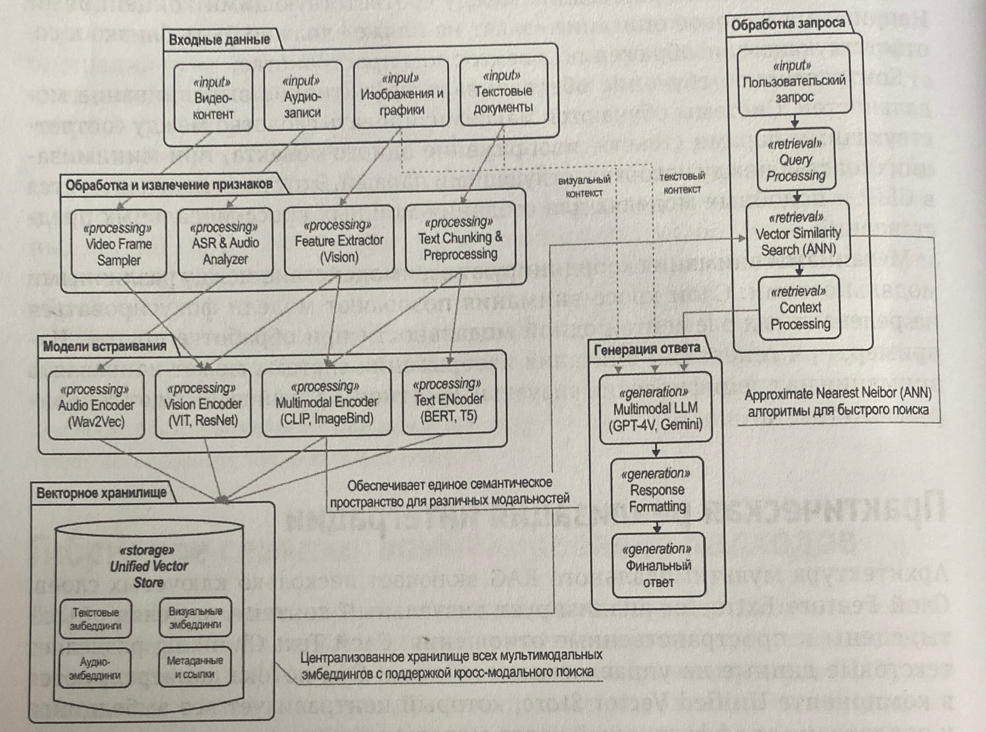

Представленная диаграмма визуализирует полный пайплайн мультимодального RAG, показывая:

1.	Входные данные разных модальностей (текст, изображения, видео, аудио).
2.	Слой обработки и извлечения признаков для каждого типа данных.
3.	Модели эмбеддингов — как специализированные для каждой модальности, так и мультимодальные.
4.	Единое векторное хранилище с различными типами эмбеддингов.
5.	Обработку запросов с векторным поиском.
6.	Генерацию ответов с использованием мультимодальных LLM.

### Инструменты и платформы

**FlashRAG:** модульный набор инструментов для исследований.

**Зачем нужен:**

- Позволяет тестировать разные способы объединения данных
- Даёт готовые стандартные интерфейсы для работы с разными форматами
- Исследователям не нужно строить инфраструктуру с нуля — можно сразу экспериментировать

**Elasticsearch + ImageBind:** корпоративная платформа для мультимодального поиска.

**Зачем нужна:**

- Эффективно индексирует и находит данные из разных форматов
- Поддерживает быстрый поиск по большим корпоративным базам
- Масштабируется под нужды бизнеса

**Milvus:** специализированная векторная база данных.

**Зачем нужна:**

- Оптимизирована для хранения и поиска сложных векторов
- Быстро извлекает информацию даже при **миллиардах** записей
- Обеспечивает низкую задержку (latency) при поиске

**Коротко:**

- **FlashRAG** — для исследований и экспериментов
- **Elasticsearch + ImageBind** — для корпоративного поиска
- **Milvus** — для масштабной работы с векторами

### Вызовы и решения

1. Разная степень детализации данных

**Проблема:**

- Текст может описывать абстрактные идеи
- Изображения фиксируют конкретные детали
- Система должна уметь сопоставлять их на **всех уровнях** — от общего к частному

2. Высокие требования к ресурсам

**Проблема:**

- Обработка изображений и видео требует **значительно больше** вычислительных мощностей, чем текст

**Решение:**

- Многоагентные системы — несколько специализированных агентов, каждый отвечает за свой тип данных

3. Сложная оценка качества

**Проблема:**

- Обычные метрики (BLEU, ROUGE) созданы для текста и **не подходят** для оценки кросс-модальных систем

**Решение:**

- Нужны специальные тесты, которые проверяют, насколько хорошо система объединяет информацию из разных источников

4. Будущее: универсальные модели

**Направление развития:**

- Создание моделей, которые обрабатывают **любое количество форматов** в одной архитектуре
- Это позволит добавлять новые типы данных **без** отдельного обучения под каждую модальность

**Коротко:** главные вызовы — разный уровень абстракции данных, высокая ресурсоёмкость и сложность оценки. Будущее — за универсальными моделями, которые работают со всеми форматами сразу.

## 14.4. Пример мультимодального пайплайна

Чтобы создать мультимодальный RAG (поиск по тексту и картинкам), нужно объединить несколько технологий: модели для обработки разных данных и векторные базы для поиска.

### Код мультимодального RAG‑пайплайна

In [ ]:
import os
import base64
from io import BytesIO
from typing import List, Dict, Any, Optional
from pathlib import Path

import torch
from PIL import Image
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from transformers import CLIPProcessor, CLIPModel
import numpy as np
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader
import openai
from openai import OpenAI


class MultimodalEmbedder:
    """Генерация эмбеддингов для текста и изображений с использованием CLIP"""

    def __init__(self, model_name: str = "openai/clip-vit-base-patch32"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = CLIPModel.from_pretrained(model_name).to(self.device)
        self.processor = CLIPProcessor.from_pretrained(model_name)

    def embed_text(self, texts: List[str]) -> np.ndarray:
        """Генерация эмбеддингов для текста"""
        inputs = self.processor(
            text=texts,
            padding=True,
            truncation=True
        ).to(self.device)

        with torch.no_grad():
            text_features = self.model.get_text_features(**inputs)
            # Нормализация для косинусного сходства
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        return text_features.cpu().numpy()

    def embed_images(self, images: List[Image.Image]) -> np.ndarray:
        """Генерация эмбеддингов для изображений"""
        inputs = self.processor(
            images=images,
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            image_features = self.model.get_image_features(**inputs)
            # Нормализация
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        return image_features.cpu().numpy()

    def embed_query(self, query: str, is_text: bool = True) -> np.ndarray:
        """Генерация эмбеддинга для запроса"""
        if is_text:
            return self.embed_text([query])
        else:
            # Для визуального запроса
            image = Image.open(query) if isinstance(query, str) else query
            return self.embed_images([image])


class MultimodalVectorStore:
    """Векторное хранилище для мультимодальных данных"""

    def __init__(self, collection_name: str = "multimodal_rag"):
        self.client = chromadb.Client()

        # Создаём коллекцию с OpenCLIP-эмбеддингами
        self.embedding_function = OpenCLIPEmbeddingFunction()

        try:
            self.collection = self.client.get_collection(
                name=collection_name,
                embedding_function=self.embedding_function
            )
        except:
            self.collection = self.client.create_collection(
                name=collection_name,
                embedding_function=self.embedding_function
            )

    def add_documents(self, texts: List[str], images: List[str],
                      embedder: MultimodalEmbedder, metadata: List[Dict] = None):
        """Добавление текстовых и визуальных документов"""

        # Обработка текстов
        if texts:
            text_embeddings = embedder.embed_text(texts)
            text_ids = [f"text_{i}" for i in range(len(texts))]

            text_metadata = [{"type": "text", "source": meta.get("source", "unknown")}
                             for meta in (metadata or [{}] * len(texts))]

            self.collection.add(
                embeddings=text_embeddings.tolist(),
                documents=texts,
                metadatas=text_metadata,
                ids=text_ids
            )

        # Обработка изображений
        if images:
            image_objects = [Image.open(img) for img in images]
            image_embeddings = embedder.embed_images(image_objects)
            image_ids = [f"image_{i}" for i in range(len(images))]

            # Конвертация изображений в base64 для хранения
            image_b64 = []
            for img_path in images:
                with open(img_path, "rb") as f:
                    img_data = base64.b64encode(f.read()).decode()
                    image_b64.append(img_data)

            image_metadata = [{"type": "image", "path": img, "base64": b64}
                              for img, b64 in zip(images, image_b64)]

            self.collection.add(
                embeddings=image_embeddings.tolist(),
                documents=[f"Image from {img}" for img in images],
                metadatas=image_metadata,
                ids=image_ids
            )

    def search(self, query_embedding: np.ndarray, n_results: int = 5) -> Dict:
        """Поиск релевантных документов (текст и изображения)"""
        results = self.collection.query(
            query_embeddings=[query_embedding.tolist()],
            n_results=n_results
        )
        return results


class MultimodalRAGPipeline:
    """Полный мультимодальный RAG-пайплайн"""

    def __init__(self, openai_api_key: str):
        self.embedder = MultimodalEmbedder()
        self.vector_store = MultimodalVectorStore()
        self.client = OpenAI(api_key=openai_api_key)

    def load_and_process_documents(self, text_dir: str, image_dir: str):
        """Загрузка и обработка текстовых и визуальных документов"""
        # Обработка текстов
        texts = []
        text_metadata = []

        if os.path.exists(text_dir):
            text_splitter = RecursiveCharacterTextSplitter(
                chunk_size=1000,
                chunk_overlap=200
            )

            for file in Path(text_dir).glob("*.txt"):
                with open(file, 'r', encoding='utf-8') as f:
                    content = f.read()
                    chunks = text_splitter.split_text(content)
                    texts.extend(chunks)
                    text_metadata.extend([{"source": str(file)}] * len(chunks))

        # Обработка изображений
        images = []
        if os.path.exists(image_dir):
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                images.extend([str(p) for p in Path(image_dir).glob(ext)])

        # Добавление в векторное хранилище
        self.vector_store.add_documents(
            texts=texts,
            images=images,
            embedder=self.embedder,
            metadata=text_metadata
        )

        print(f"Загружено {len(texts)} текстовых фрагментов и {len(images)} изображений")

    def query(self, user_query: str, use_vision: bool = True) -> str:
        """Обработка запроса с мультимодальной генерацией"""

        # Генерация эмбеддинга запроса
        query_embedding = self.embedder.embed_query(user_query)

        # Поиск релевантных документов
        search_results = self.vector_store.search(query_embedding, n_results=5)

        # Разделение текстовых и визуальных результатов
        text_context = []
        image_contexts = []

        for i, metadata in enumerate(search_results['metadatas']):
            if metadata['type'] == 'text':
                text_context.append(search_results['documents'][i])
            elif metadata['type'] == 'image':
                image_contexts.append(metadata['base64'])

        # Формирование промпта
        context_text = "\n\n".join(text_context)

        # Генерация ответа с GPT-4 Vision
        if use_vision and image_contexts:
            messages = [
                {
                    "role": "system",
                    "content": "Вы - полезный ассистент, который отвечает на вопросы на основе предоставленного текста и изображений."
                },
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "text",
                            "text": f"Контекст:\n{context_text}\n\nВопрос: {user_query}"
                        }
                    ] + [
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{img}"
                            }
                        }
                        for img in image_contexts[:3]  # Максимум 3 изображения
                    ]
                }
            ]

            response = self.client.chat.completions.create(
                model="gpt-4o",
                messages=messages,
                max_tokens=1000
            )
        else:
            # Обычная генерация без визуального контекста
            response = self.client.chat.completions.create(
                model="gpt-4",
                messages=[
                    {
                        "role": "system",
                        "content": "Вы - полезный ассистент, который отвечает на вопросы на основе предоставленного контекста."
                    },
                    {
                        "role": "user",
                        "content": f"Контекст:\n{context_text}\n\nВопрос: {user_query}"
                    }
                ],
                max_tokens=1000
            )

        return response.choices.message.content


# Пример использования
def main():
    """Демонстрация работы мультимодального RAG"""

    # Инициализация пайплайна
    rag = MultimodalRAGPipeline(
        openai_api_key=os.getenv("OPENAI_API_KEY")
    )

    # Загрузка документов
    rag.load_and_process_documents(
        text_dir="./documents/texts",
        image_dir="./documents/images"
    )

    # Примеры запросов
    queries = [
        "Что показано на диаграммах роста выручки?",
        "Опиши архитектуру системы на основе схемы",
        "Какие ключевые метрики упоминаются в документах?"
    ]

    for query in queries:
        print(f"\n{'='*60}")
        print(f"Вопрос: {query}")
        print(f"{'='*60}")
        answer = rag.query(query, use_vision=True)
        print(f"Ответ: {answer}\n")


if __name__ == "__main__":
    main()

Пайплайн состоит из трёх частей, каждая решает свою задачу.

**1. MultimodalEmbedder**

Переводит текст и картинки в одно общее векторное пространство с помощью CLIP. Благодаря этому можно искать и по тексту, и по изображениям одновременно (кросс-модальный поиск).

**2. MultimodalVectorStore**

Хранит и ищет эти векторы в базе ChromaDB. Обеспечивает быструю индексацию и быстрый поиск нужных документов.

**3. MultimodalRAGPipeline**

Собирает всё вместе в один процесс:
- автоматически разбивает тексты на части и обрабатывает картинки;
- сохраняет всё в векторную базу;
- при запросе ищет подходящий текст и изображения;
- передаёт найденное в GPT-4 Vision;
- получает ответ, который учитывает и текст, и картинки.

**Итог:** система сама обрабатывает документы и отвечает на вопросы, используя сразу и текст, и визуальную информацию.